# ECG Classification: CBAM-ResNet18 with Anti-Overfitting

**Research-Backed Improvements for MIT-BIH Arrhythmia Dataset**

---

## Key Enhancements Based on Literature

| Technique | Purpose | Config |
|-----------|---------|--------|
| **DropBlock** | Drops contiguous regions in feature maps | block_size=7, p=0.15 |
| **Stochastic Depth** | Randomly drops residual blocks | p=0.2 linear decay |
| **CutMix** | Patches from different samples (better than MixUp) | beta=1.0, p=0.5 |
| **Focal Loss** | Down-weights easy samples | gamma=2.0 |
| **Label Smoothing** | Prevents overconfident predictions | epsilon=0.1 |
| **1D Signal Aug** | Noise + time warp before encoding | noise=0.02 |
| **Cosine Annealing** | Better LR schedule | T_max=30 |

---

## 1. Environment Setup

In [1]:
!pip install pyts -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: C:\Users\HP\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## 2. Enhanced Configuration

In [2]:
CONFIG = {
    # Data Settings
    'encoding_type': 'fusion',
    'image_size': 64,
    'batch_size': 32,
    'val_split': 0.1,
    'seed': 42,
    'num_classes': 5,
    'quick_test': False,
    
    # Training
    'epochs': 30,
    'learning_rate': 0.001,
    
    # ANTI-OVERFITTING TECHNIQUES
    'use_dropblock': True,
    'dropblock_size': 7,
    'dropblock_prob': 0.15,
    
    'use_stochastic_depth': True,
    'stochastic_depth_prob': 0.2,
    
    'use_cutmix': True,
    'cutmix_prob': 0.5,
    'cutmix_beta': 1.0,
    
    'use_focal_loss': True,
    'focal_gamma': 2.0,
    
    'use_label_smoothing': True,
    'label_smoothing': 0.1,
    
    'use_signal_augmentation': True,
    'noise_std': 0.02,
    'time_warp_prob': 0.3,
    
    # Regularization
    'weight_decay': 5e-4,
    'weight_decay_cbam': 1e-3,
    'gradient_clip': 1.0,
    
    # LR Schedule
    'use_cosine_annealing': True,
    'cosine_T_max': 30,
    'cosine_eta_min': 1e-6,
    
    # Early Stopping
    'early_stopping_patience': 10,
}

np.random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed(CONFIG['seed'])

print('=' * 70)
print('ENHANCED EXPERIMENT CONFIGURATION')
print('=' * 70)
for k, v in CONFIG.items():
    print(f'  {k:.<40} {v}')
print('=' * 70)


ENHANCED EXPERIMENT CONFIGURATION
  encoding_type........................... fusion
  image_size.............................. 64
  batch_size.............................. 32
  val_split............................... 0.1
  seed.................................... 42
  num_classes............................. 5
  quick_test.............................. False
  epochs.................................. 30
  learning_rate........................... 0.001
  use_dropblock........................... True
  dropblock_size.......................... 7
  dropblock_prob.......................... 0.15
  use_stochastic_depth.................... True
  stochastic_depth_prob................... 0.2
  use_cutmix.............................. True
  cutmix_prob............................. 0.5
  cutmix_beta............................. 1.0
  use_focal_loss.......................... True
  focal_gamma............................. 2.0
  use_label_smoothing..................... True
  label_smoothing....

## 3. Data Loading

**MIT-BIH Heartbeat Dataset:**
- 5 classes: N (Normal), S (Supraventricular), V (Ventricular), F (Fusion), Q (Unknown)
- Severe class imbalance (~83% Normal)
- Requires proper handling to prevent overfitting to majority class

In [4]:
# Load data
train_df = pd.read_csv("ECG_dataset\mitbih_train.csv", header=None)
test_df = pd.read_csv("ECG_dataset\mitbih_train.csv", header=None)

print(f'Train file: {len(train_df):,} samples')
print(f'Test file: {len(test_df):,} samples')

X_full = train_df.iloc[:, :-1].values
y_full = train_df.iloc[:, -1].values.astype(int)
X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values.astype(int)

# Train/Val split
X_train, X_val, y_train, y_val = train_test_split(
    X_full, y_full, 
    test_size=CONFIG['val_split'], 
    random_state=CONFIG['seed'],
    stratify=y_full
)

if CONFIG['quick_test']:
    X_train, y_train = X_train[:5000], y_train[:5000]
    X_val, y_val = X_val[:1000], y_val[:1000]
    X_test, y_test = X_test[:1000], y_test[:1000]
    print('[QUICK TEST MODE]')

print(f'\nData Split:')
print(f'  Train: {len(X_train):,} samples')
print(f'  Val:   {len(X_val):,} samples')
print(f'  Test:  {len(X_test):,} samples')

CLASS_NAMES = ['N (Normal)', 'S (Supra)', 'V (Vent)', 'F (Fusion)', 'Q (Unknown)']
CLASS_COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']


Train file: 87,554 samples
Test file: 87,554 samples

Data Split:
  Train: 78,798 samples
  Val:   8,756 samples
  Test:  87,554 samples


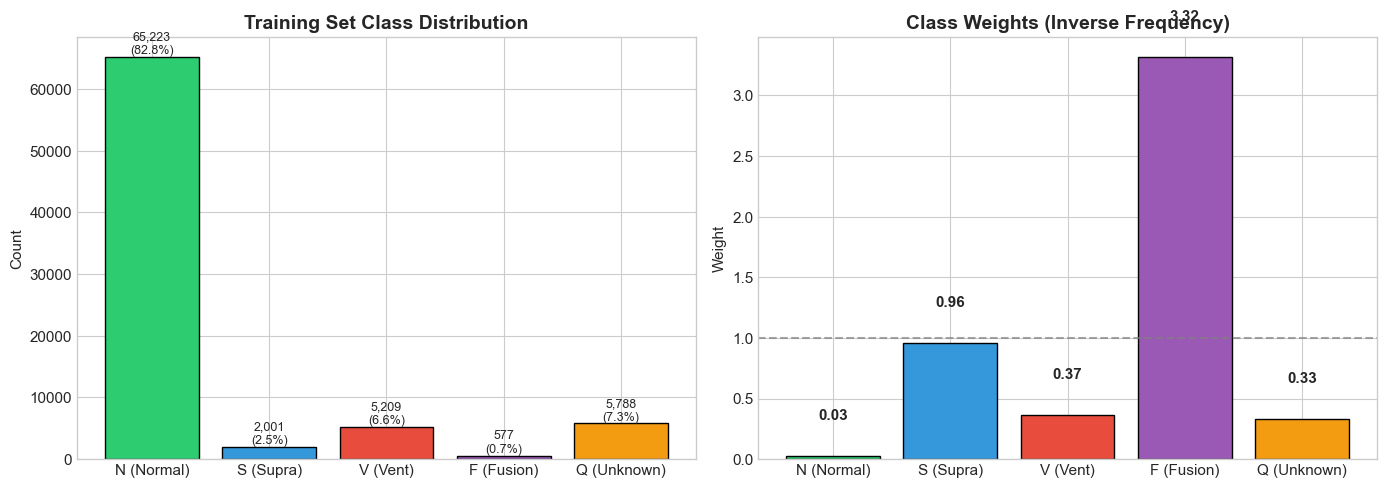

In [5]:
# Class Distribution and Weights
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unique, counts = np.unique(y_train, return_counts=True)
bars = axes[0].bar(CLASS_NAMES, counts, color=CLASS_COLORS, edgecolor='black')
axes[0].set_title('Training Set Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
                 f'{count:,}\n({count/len(y_train)*100:.1f}%)', ha='center', fontsize=9)

# Class weights for Focal Loss
class_weights = len(y_train) / (len(unique) * counts)
class_weights = class_weights / class_weights.sum() * len(unique)

bars2 = axes[1].bar(CLASS_NAMES, class_weights, color=CLASS_COLORS, edgecolor='black')
axes[1].set_title('Class Weights (Inverse Frequency)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Weight')
axes[1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.7)
for bar, w in zip(bars2, class_weights):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{w:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Signal Augmentation (1D - Before Encoding)

**Critical Insight**: Augmenting the raw 1D signal BEFORE GAF/RP/MTF encoding is safer than augmenting the 2D images, as it preserves the mathematical validity of the transformations.

In [6]:
def augment_signal_1d(signal, training=True):
    '''Apply augmentations to 1D ECG signal before encoding'''
    if not training or not CONFIG['use_signal_augmentation']:
        return signal
    
    signal = signal.copy()
    
    # 1. Gaussian noise injection (simulates sensor noise)
    if np.random.random() < 0.5:
        noise = np.random.normal(0, CONFIG['noise_std'], signal.shape)
        signal = signal + noise
    
    # 2. Random amplitude scaling (simulates gain variations)
    if np.random.random() < 0.3:
        scale = np.random.uniform(0.9, 1.1)
        signal = signal * scale
    
    # 3. Time warping (simulates heart rate variability)
    if np.random.random() < CONFIG['time_warp_prob']:
        # Stretch/compress random segment
        n = len(signal)
        warp_point = np.random.randint(n//4, 3*n//4)
        warp_factor = np.random.uniform(0.9, 1.1)
        
        left = signal[:warp_point]
        right = signal[warp_point:]
        
        # Resample left segment
        new_len_left = int(len(left) * warp_factor)
        if new_len_left > 0:
            left = np.interp(
                np.linspace(0, len(left)-1, new_len_left),
                np.arange(len(left)),
                left
            )
        
        # Adjust right to maintain length
        new_len_right = n - len(left)
        if new_len_right > 0:
            right = np.interp(
                np.linspace(0, len(right)-1, new_len_right),
                np.arange(len(right)),
                right
            )
        
        signal = np.concatenate([left, right])[:n]
        if len(signal) < n:
            signal = np.pad(signal, (0, n - len(signal)), mode='edge')
    
    # 4. Random baseline shift
    if np.random.random() < 0.3:
        shift = np.random.uniform(-0.05, 0.05)
        signal = signal + shift
    
    return signal

print('1D Signal augmentation functions defined')
print(f'  - Noise injection: std={CONFIG["noise_std"]}')
print(f'  - Time warp probability: {CONFIG["time_warp_prob"]}')


1D Signal augmentation functions defined
  - Noise injection: std=0.02
  - Time warp probability: 0.3


## 5. Fusion Encoding (GAF + RP + MTF)

In [7]:
from pyts.image import GramianAngularField
from sklearn.metrics import pairwise_distances

gaf = GramianAngularField(image_size=CONFIG['image_size'], method='summation')

def create_rp(signal, size):
    '''Create Recurrence Plot'''
    idx = np.linspace(0, len(signal)-1, size).astype(int)
    s = signal[idx].reshape(-1, 1)
    D = pairwise_distances(s, metric='euclidean')
    return (D < np.percentile(D, 20)).astype(float)

def create_mtf(signal, size, n_bins=5):
    '''Create Markov Transition Field'''
    bins = np.percentile(signal, np.linspace(0, 100, n_bins + 1))
    digitized = np.clip(np.digitize(signal, bins[:-1]) - 1, 0, n_bins - 1)
    trans = np.zeros((n_bins, n_bins))
    for i in range(len(digitized) - 1):
        trans[digitized[i], digitized[i+1]] += 1
    trans = trans / (trans.sum(axis=1, keepdims=True) + 1e-8)
    idx = np.linspace(0, len(digitized)-1, size).astype(int)
    mtf = np.zeros((size, size))
    for i in range(size):
        for j in range(size):
            mtf[i, j] = trans[digitized[idx[i]], digitized[idx[j]]]
    return mtf

print('Fusion encoding: GAF + RP + MTF')


Fusion encoding: GAF + RP + MTF


## 6. CutMix Augmentation (2D)

**Why CutMix > MixUp for GAF/RP/MTF:**
- MixUp blends images linearly, creating ghostly overlays with no physical meaning
- CutMix cuts and pastes patches, simulating temporal segment splicing
- Forces CBAM to use spatial attention to locate anomalies

In [8]:
def cutmix_data(x, y, alpha=1.0):
    '''
    CutMix: Cut and paste patches between samples
    Better than MixUp for GAF/RP/MTF images
    '''
    batch_size = x.size(0)
    indices = torch.randperm(batch_size).to(x.device)
    
    # Sample lambda from beta distribution
    lam = np.random.beta(alpha, alpha)
    
    # Get bounding box
    W, H = x.size(2), x.size(3)
    cut_rat = np.sqrt(1. - lam)
    cut_w = int(W * cut_rat)
    cut_h = int(H * cut_rat)
    
    # Random center
    cx = np.random.randint(W)
    cy = np.random.randint(H)
    
    # Bounding box
    bbx1 = np.clip(cx - cut_w // 2, 0, W)
    bby1 = np.clip(cy - cut_h // 2, 0, H)
    bbx2 = np.clip(cx + cut_w // 2, 0, W)
    bby2 = np.clip(cy + cut_h // 2, 0, H)
    
    # Apply cutmix
    x_mixed = x.clone()
    x_mixed[:, :, bbx1:bbx2, bby1:bby2] = x[indices, :, bbx1:bbx2, bby1:bby2]
    
    # Adjust lambda based on actual box area
    lam = 1 - ((bbx2 - bbx1) * (bby2 - bby1) / (W * H))
    
    y_a, y_b = y, y[indices]
    return x_mixed, y_a, y_b, lam

def cutmix_criterion(criterion, pred, y_a, y_b, lam):
    '''Compute CutMix loss'''
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print('CutMix augmentation defined')


CutMix augmentation defined


In [9]:
class ECGFusionDataset(Dataset):
    def __init__(self, signals, labels, image_size, training=True):
        self.signals = signals
        self.labels = labels
        self.image_size = image_size
        self.training = training
        self.gaf = GramianAngularField(image_size=image_size, method='summation')
    
    def __len__(self):
        return len(self.signals)
    
    def __getitem__(self, idx):
        signal = self.signals[idx]
        
        # Apply 1D augmentation before encoding
        if self.training:
            signal = augment_signal_1d(signal, training=True)
        
        # Create encoded images
        gaf_img = self.gaf.transform(signal.reshape(1, -1))[0]
        rp_img = create_rp(signal, self.image_size)
        mtf_img = create_mtf(signal, self.image_size)
        
        # Stack as 3-channel image
        img = np.stack([gaf_img, rp_img, mtf_img], axis=0)
        
        return torch.tensor(img, dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)

print('Creating datasets...')
train_dataset = ECGFusionDataset(X_train, y_train, CONFIG['image_size'], training=True)
val_dataset = ECGFusionDataset(X_val, y_val, CONFIG['image_size'], training=False)
test_dataset = ECGFusionDataset(X_test, y_test, CONFIG['image_size'], training=False)

train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=CONFIG['batch_size'], shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')


Creating datasets...
Train batches: 2463
Val batches: 274
Test batches: 2737


## 7. DropBlock Module

**DropBlock vs Dropout:**
- Standard Dropout fails in conv layers due to spatial correlation
- DropBlock zeros out contiguous regions (7x7 blocks)
- Forces CBAM to find secondary discriminative features

In [10]:
class DropBlock2D(nn.Module):
    '''
    DropBlock: Drops contiguous regions in feature maps
    Better regularization for CNNs than standard Dropout
    '''
    def __init__(self, block_size=7, drop_prob=0.15):
        super().__init__()
        self.block_size = block_size
        self.drop_prob = drop_prob
    
    def forward(self, x):
        if not self.training or self.drop_prob == 0:
            return x
        
        # Calculate gamma (probability of dropping each pixel)
        gamma = self.drop_prob / (self.block_size ** 2)
        gamma *= (x.shape[-1] ** 2) / ((x.shape[-1] - self.block_size + 1) ** 2)
        
        # Sample mask
        mask = (torch.rand_like(x[:, :1, :, :]) < gamma).float()
        
        # Expand mask using max pooling
        mask = F.max_pool2d(
            mask, 
            kernel_size=(self.block_size, self.block_size),
            stride=1,
            padding=self.block_size // 2
        )
        mask = 1 - mask
        
        # Normalize by percentage of active units
        normalize = mask.numel() / (mask.sum() + 1e-8)
        
        return x * mask * normalize

print(f'DropBlock defined: block_size={CONFIG["dropblock_size"]}, prob={CONFIG["dropblock_prob"]}')


DropBlock defined: block_size=7, prob=0.15


## 8. Focal Loss with Label Smoothing

**Focal Loss** (γ=2.0): Down-weights easy samples, focuses on hard minority classes
**Label Smoothing** (ε=0.1): Prevents overconfident predictions

In [11]:
class FocalLossWithSmoothing(nn.Module):
    '''
    Focal Loss with Label Smoothing
    - Focal: down-weights easy samples with (1-pt)^gamma
    - Smoothing: soft targets prevent overconfidence
    '''
    def __init__(self, gamma=2.0, alpha=None, smoothing=0.1, weight=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.smoothing = smoothing
        self.weight = weight
    
    def forward(self, pred, target):
        n_classes = pred.size(1)
        
        # Label smoothing
        if self.smoothing > 0:
            with torch.no_grad():
                smooth_target = torch.zeros_like(pred)
                smooth_target.fill_(self.smoothing / (n_classes - 1))
                smooth_target.scatter_(1, target.unsqueeze(1), 1 - self.smoothing)
        else:
            smooth_target = F.one_hot(target, n_classes).float()
        
        # Compute log softmax
        log_probs = F.log_softmax(pred, dim=1)
        probs = torch.exp(log_probs)
        
        # Focal weight
        focal_weight = (1 - probs) ** self.gamma
        
        # Compute loss
        loss = -focal_weight * smooth_target * log_probs
        loss = loss.sum(dim=1)
        
        # Apply class weights
        if self.weight is not None:
            loss = loss * self.weight[target]
        
        return loss.mean()

print(f'Focal Loss defined: gamma={CONFIG["focal_gamma"]}, smoothing={CONFIG["label_smoothing"]}')


Focal Loss defined: gamma=2.0, smoothing=0.1


## 9. CBAM Attention Module

In [12]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Dropout(0.1),  # Dropout in attention MLP
            nn.Conv2d(channels // reduction, channels, 1, bias=False)
        )
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        return self.sigmoid(self.fc(self.avg_pool(x)) + self.fc(self.max_pool(x)))

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size//2, bias=False)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        return self.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))

class CBAM(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction)
        self.sa = SpatialAttention()
    
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x

print('CBAM: Channel + Spatial Attention')


CBAM: Channel + Spatial Attention


## 10. Stochastic Depth

Randomly drops entire residual blocks during training.
Creates implicit ensemble of 2^L shallower networks.

In [13]:
def stochastic_depth(x, survival_prob, training):
    '''
    Stochastic Depth: randomly skip residual blocks
    survival_prob: probability of keeping the block
    '''
    if not training or survival_prob >= 1.0:
        return x
    
    # Random survival decision
    if torch.rand(1).item() > survival_prob:
        return torch.zeros_like(x)
    
    # Scale output during training
    return x / survival_prob

print(f'Stochastic Depth: max_drop_prob={CONFIG["stochastic_depth_prob"]}')


Stochastic Depth: max_drop_prob=0.2


## 11. Enhanced ResNet-18 + CBAM Model

In [14]:
class ResNetCBAM_Enhanced(nn.Module):
    '''
    ResNet-18 with CBAM attention and anti-overfitting enhancements:
    - DropBlock in layer3/layer4
    - Stochastic Depth on residual connections
    - Dropout in classification head
    '''
    def __init__(self, num_classes=5, dropblock_prob=0.15, stochastic_depth_prob=0.2):
        super().__init__()
        self.backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        
        # CBAM attention modules
        self.cbam1 = CBAM(64)
        self.cbam2 = CBAM(128)
        self.cbam3 = CBAM(256)
        self.cbam4 = CBAM(512)
        
        # DropBlock for layer3 and layer4
        self.dropblock3 = DropBlock2D(block_size=CONFIG['dropblock_size'], drop_prob=dropblock_prob * 0.5)
        self.dropblock4 = DropBlock2D(block_size=CONFIG['dropblock_size'], drop_prob=dropblock_prob)
        
        # Stochastic depth survival probabilities (linear decay)
        self.survival_probs = [
            1.0 - stochastic_depth_prob * (i / 4) for i in range(1, 5)
        ]
        
        # Enhanced classification head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        # Initial conv
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)
        
        # Layer 1 + CBAM
        identity = x
        x = self.backbone.layer1(x)
        x = self.cbam1(x)
        if CONFIG['use_stochastic_depth']:
            x = identity + stochastic_depth(x - identity, self.survival_probs[0], self.training)
        
        # Layer 2 + CBAM
        identity = F.avg_pool2d(x, 2) if x.shape[-1] != self.backbone.layer2(x[:1]).shape[-1] else x
        x = self.backbone.layer2(x)
        x = self.cbam2(x)
        
        # Layer 3 + CBAM + DropBlock
        x = self.backbone.layer3(x)
        x = self.cbam3(x)
        if CONFIG['use_dropblock']:
            x = self.dropblock3(x)
        
        # Layer 4 + CBAM + DropBlock
        x = self.backbone.layer4(x)
        x = self.cbam4(x)
        if CONFIG['use_dropblock']:
            x = self.dropblock4(x)
        
        # Classification
        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.fc(x)
        
        return x

model = ResNetCBAM_Enhanced(
    num_classes=CONFIG['num_classes'],
    dropblock_prob=CONFIG['dropblock_prob'],
    stochastic_depth_prob=CONFIG['stochastic_depth_prob']
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: ResNet-18 + CBAM Enhanced')
print(f'Total parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')


Model: ResNet-18 + CBAM Enhanced
Total parameters: 11,386,061
Trainable parameters: 11,386,061


## 12. Training Setup

In [15]:
# Loss function
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

if CONFIG['use_focal_loss']:
    criterion = FocalLossWithSmoothing(
        gamma=CONFIG['focal_gamma'],
        smoothing=CONFIG['label_smoothing'] if CONFIG['use_label_smoothing'] else 0,
        weight=class_weights_tensor
    )
    print(f'Loss: Focal Loss (gamma={CONFIG["focal_gamma"]}) + Label Smoothing (eps={CONFIG["label_smoothing"]})')
else:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=CONFIG['label_smoothing'])
    print(f'Loss: CrossEntropy + Label Smoothing (eps={CONFIG["label_smoothing"]})')

# Optimizer with separate weight decay for CBAM
cbam_params = []
other_params = []
for name, param in model.named_parameters():
    if 'cbam' in name or 'ca' in name or 'sa' in name:
        cbam_params.append(param)
    else:
        other_params.append(param)

optimizer = optim.AdamW([
    {'params': other_params, 'weight_decay': CONFIG['weight_decay']},
    {'params': cbam_params, 'weight_decay': CONFIG['weight_decay_cbam']}
], lr=CONFIG['learning_rate'])

print(f'Optimizer: AdamW (weight_decay={CONFIG["weight_decay"]}, cbam_decay={CONFIG["weight_decay_cbam"]})')

# Learning rate scheduler
if CONFIG['use_cosine_annealing']:
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, 
        T_max=CONFIG['cosine_T_max'],
        eta_min=CONFIG['cosine_eta_min']
    )
    print(f'Scheduler: Cosine Annealing (T_max={CONFIG["cosine_T_max"]})')
else:
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', patience=3, factor=0.5)
    print('Scheduler: ReduceLROnPlateau')

# History
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_f1': [], 'lr': []}
best_f1 = 0
best_epoch = 0
best_model_state = None
patience_counter = 0


Loss: Focal Loss (gamma=2.0) + Label Smoothing (eps=0.1)
Optimizer: AdamW (weight_decay=0.0005, cbam_decay=0.001)
Scheduler: Cosine Annealing (T_max=30)


## 13. Training Loop with CutMix

In [16]:
print('=' * 80)
print('STARTING ENHANCED TRAINING')
print('=' * 80)
print(f'   Epochs: {CONFIG["epochs"]}')
print(f'   Early stopping patience: {CONFIG["early_stopping_patience"]}')
print(f'   CutMix: {CONFIG["use_cutmix"]} (prob={CONFIG["cutmix_prob"]})')
print(f'   DropBlock: {CONFIG["use_dropblock"]}')
print(f'   Stochastic Depth: {CONFIG["use_stochastic_depth"]}')
print('=' * 80)

for epoch in range(CONFIG['epochs']):
    print()
    print('=' * 80)
    print(f'EPOCH {epoch+1}/{CONFIG["epochs"]}')
    print('=' * 80)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Learning Rate: {current_lr:.6f}')
    
    # Training phase
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1} [TRAIN]', 
                      bar_format='{l_bar}{bar:30}{r_bar}')
    
    for batch_idx, (data, target) in enumerate(train_pbar):
        data, target = data.to(device), target.to(device)
        
        # Apply CutMix with probability
        use_cutmix = CONFIG['use_cutmix'] and np.random.random() < CONFIG['cutmix_prob']
        
        if use_cutmix:
            data, y_a, y_b, lam = cutmix_data(data, target, CONFIG['cutmix_beta'])
            output = model(data)
            loss = cutmix_criterion(criterion, output, y_a, y_b, lam)
        else:
            output = model(data)
            loss = criterion(output, target)
        
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        if CONFIG['gradient_clip']:
            torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG['gradient_clip'])
        
        optimizer.step()
        
        train_loss += loss.item() * data.size(0)
        if use_cutmix:
            # For CutMix, count correct based on dominant label
            train_correct += (lam * (output.argmax(1) == y_a).sum().item() + 
                            (1 - lam) * (output.argmax(1) == y_b).sum().item())
        else:
            train_correct += (output.argmax(1) == target).sum().item()
        train_total += target.size(0)
        
        train_pbar.set_postfix(loss=f'{train_loss/train_total:.4f}', acc=f'{train_correct/train_total*100:.2f}%')
    
    train_loss /= train_total
    train_acc = train_correct / train_total
    
    # Validation phase
    model.eval()
    val_loss, val_preds, val_labels = 0, [], []
    val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1} [VAL]  ', 
                    bar_format='{l_bar}{bar:30}{r_bar}')
    
    with torch.no_grad():
        for data, target in val_pbar:
            data, target = data.to(device), target.to(device)
            output = model(data)
            val_loss += criterion(output, target).item() * data.size(0)
            val_preds.extend(output.argmax(1).cpu().numpy())
            val_labels.extend(target.cpu().numpy())
    
    val_loss /= len(val_labels)
    val_acc = accuracy_score(val_labels, val_preds)
    val_f1 = f1_score(val_labels, val_preds, average='macro')
    
    # Update history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)
    
    # Update scheduler
    if CONFIG['use_cosine_annealing']:
        scheduler.step()
    else:
        scheduler.step(val_f1)
    
    # Print summary
    print()
    print(f'EPOCH {epoch+1} SUMMARY:')
    print(f'   Train -> Loss: {train_loss:.4f} | Accuracy: {train_acc*100:.2f}%')
    print(f'   Val   -> Loss: {val_loss:.4f} | Accuracy: {val_acc*100:.2f}% | F1-Macro: {val_f1*100:.2f}%')
    print(f'   Train-Val Gap: {(train_acc - val_acc)*100:.2f}%')  # Overfitting indicator
    
    # Best model tracking
    if val_f1 > best_f1:
        best_f1 = val_f1
        best_epoch = epoch + 1
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        print()
        print('   *** NEW BEST MODEL ***')
        print(f'   Validation F1-Macro: {val_f1*100:.2f}%')
    else:
        patience_counter += 1
        print(f'   No improvement. Patience: {patience_counter}/{CONFIG["early_stopping_patience"]}')
    
    # Early stopping
    if patience_counter >= CONFIG['early_stopping_patience']:
        print()
        print('=' * 80)
        print(f'EARLY STOPPING at epoch {epoch+1}')
        print('=' * 80)
        break

print()
print('=' * 80)
print('TRAINING COMPLETED')
print('=' * 80)
print(f'   Best Model: Epoch {best_epoch}')
print(f'   Best Val F1-Macro: {best_f1*100:.2f}%')
print('=' * 80)

# Load best model
if best_model_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    print(f'Loaded best model from epoch {best_epoch}')


STARTING ENHANCED TRAINING
   Epochs: 30
   Early stopping patience: 10
   CutMix: True (prob=0.5)
   DropBlock: True
   Stochastic Depth: True

EPOCH 1/30
Learning Rate: 0.001000


Epoch 1 [VAL]  : 100%|██████████████████████████████| 274/274 [00:47<00:00,  5.81it/s]



EPOCH 1 SUMMARY:
   Train -> Loss: 0.0887 | Accuracy: 47.84%
   Val   -> Loss: 0.0611 | Accuracy: 71.90% | F1-Macro: 52.98%
   Train-Val Gap: -24.06%

   *** NEW BEST MODEL ***
   Validation F1-Macro: 52.98%

EPOCH 2/30
Learning Rate: 0.000997


Epoch 2 [VAL]  : 100%|██████████████████████████████| 274/274 [00:44<00:00,  6.14it/s]



EPOCH 2 SUMMARY:
   Train -> Loss: 0.0771 | Accuracy: 60.13%
   Val   -> Loss: 0.0526 | Accuracy: 75.70% | F1-Macro: 55.32%
   Train-Val Gap: -15.57%

   *** NEW BEST MODEL ***
   Validation F1-Macro: 55.32%

EPOCH 3/30
Learning Rate: 0.000989


...


EPOCH 28 SUMMARY:
   Train -> Loss: 0.0488 | Accuracy: 80.75%
   Val   -> Loss: 0.0369 | Accuracy: 96.21% | F1-Macro: 83.07%
   Train-Val Gap: -15.45%

   *** NEW BEST MODEL ***
   Validation F1-Macro: 83.07%

EPOCH 29/30
Learning Rate: 0.000012


Epoch 29 [VAL]  : 100%|██████████████████████████████| 274/274 [00:46<00:00,  5.93it/s]



EPOCH 29 SUMMARY:
   Train -> Loss: 0.0489 | Accuracy: 80.92%
   Val   -> Loss: 0.0370 | Accuracy: 95.26% | F1-Macro: 80.56%
   Train-Val Gap: -14.34%
   No improvement. Patience: 1/10

EPOCH 30/30
Learning Rate: 0.000004


Epoch 30 [VAL]  : 100%|██████████████████████████████| 274/274 [00:50<00:00,  5.41it/s]



EPOCH 30 SUMMARY:
   Train -> Loss: 0.0487 | Accuracy: 81.05%
   Val   -> Loss: 0.0379 | Accuracy: 91.21% | F1-Macro: 74.90%
   Train-Val Gap: -10.16%
   No improvement. Patience: 2/10

TRAINING COMPLETED
   Best Model: Epoch 28
   Best Val F1-Macro: 83.07%
Loaded best model from epoch 28


In [27]:
import os, json
import torch
import pandas as pd

save_dir = "checkpoints"
os.makedirs(save_dir, exist_ok=True)

# 1) Save best model weights
best_path = os.path.join(save_dir, "best_model.pth")
if best_model_state is not None:
    torch.save(best_model_state, best_path)
else:
    torch.save(model.state_dict(), best_path)
print(f"Saved best model to: {best_path}")

# 2) Save history (CSV + JSON)
hist_df = pd.DataFrame(history)
hist_csv = os.path.join(save_dir, "history.csv")
hist_json = os.path.join(save_dir, "history.json")
hist_df.to_csv(hist_csv, index=False)
with open(hist_json, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2, ensure_ascii=False)
print(f"Saved history to: {hist_csv} and {hist_json}")

# 3) (Optional but recommended) save a single checkpoint with both
ckpt_path = os.path.join(save_dir, "checkpoint_best_with_history.pth")
ckpt = {
    "best_epoch": best_epoch,
    "best_val_f1_macro": float(best_f1),
    "model_state_dict": best_model_state if best_model_state is not None else model.state_dict(),
    "history": history,
    "config": CONFIG,
}
torch.save(ckpt, ckpt_path)
print(f"Saved checkpoint to: {ckpt_path}")

# to reload for reusing do this!
#ckpt = torch.load("checkpoints/checkpoint_best_with_history.pth", map_location=device)
#model.load_state_dict(ckpt["model_state_dict"])
#history = ckpt["history"]


Saved best model to: checkpoints\best_model.pth
Saved history to: checkpoints\history.csv and checkpoints\history.json
Saved checkpoint to: checkpoints\checkpoint_best_with_history.pth


## 14. Training Visualization

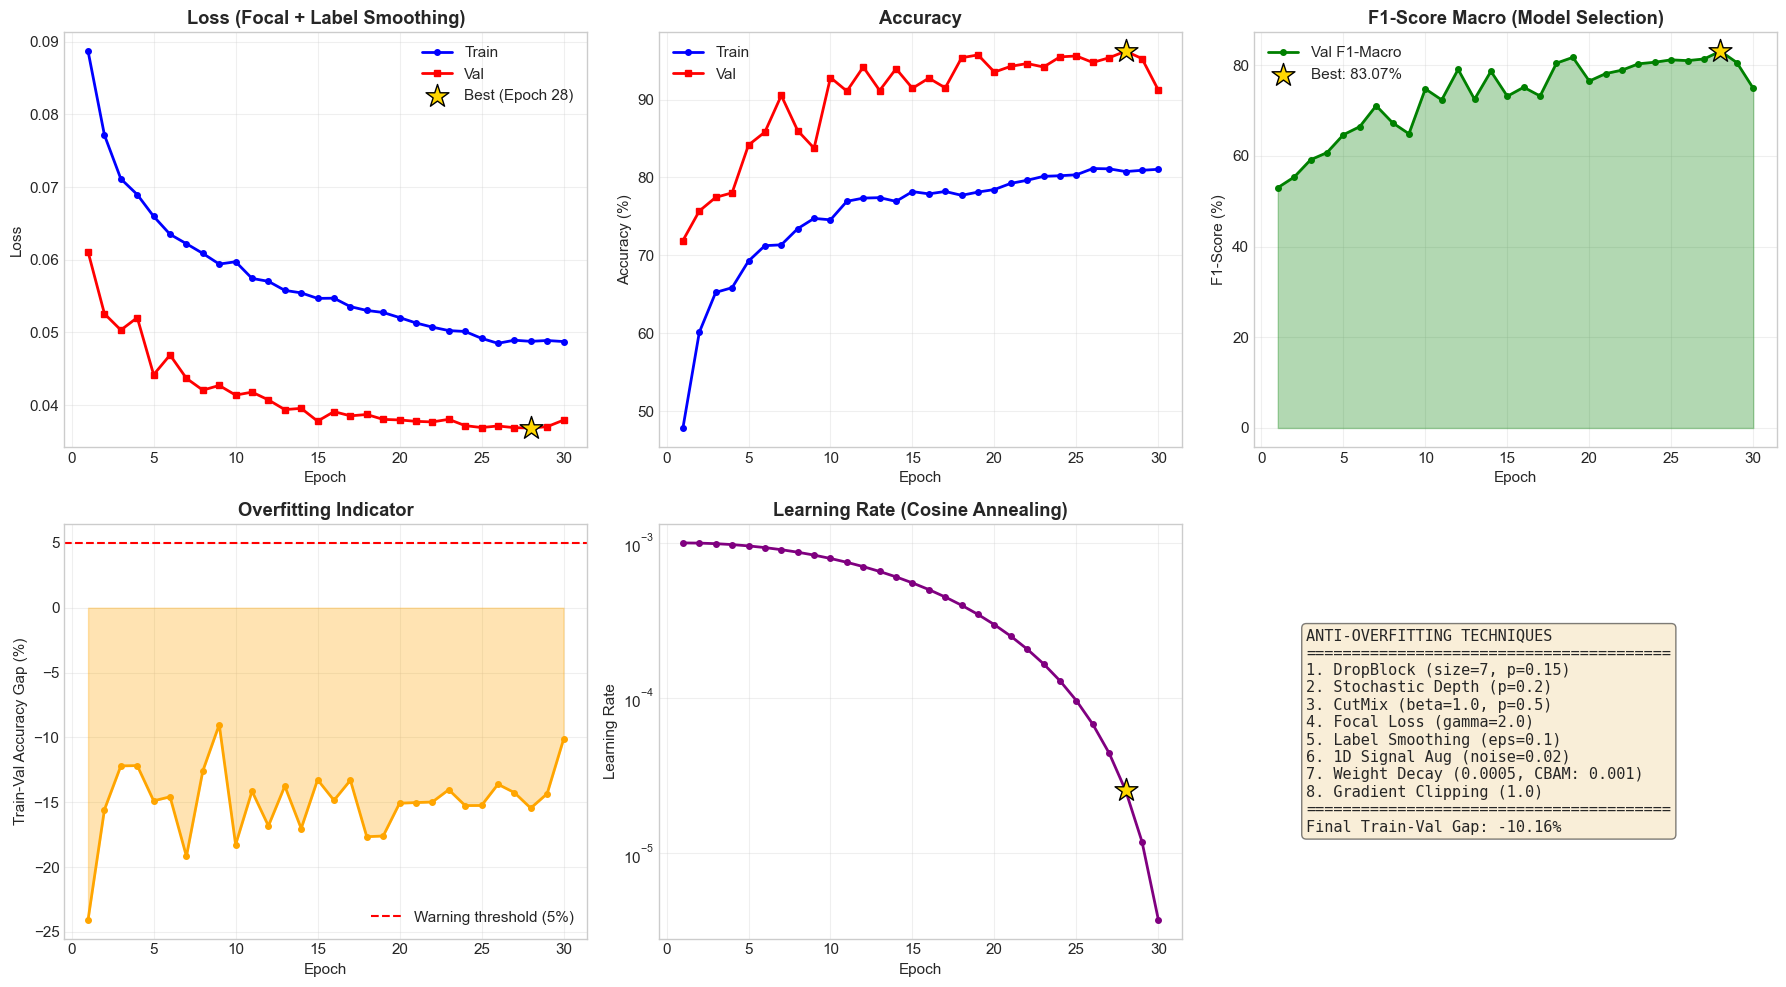

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
epochs_range = range(1, len(history['train_loss']) + 1)

# Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-o', label='Train', lw=2, ms=4)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-s', label='Val', lw=2, ms=4)
axes[0, 0].scatter([best_epoch], [history['val_loss'][best_epoch-1]], s=300, c='gold', marker='*', 
                   edgecolors='black', zorder=5, label=f'Best (Epoch {best_epoch})')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss (Focal + Label Smoothing)', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs_range, [x*100 for x in history['train_acc']], 'b-o', label='Train', lw=2, ms=4)
axes[0, 1].plot(epochs_range, [x*100 for x in history['val_acc']], 'r-s', label='Val', lw=2, ms=4)
axes[0, 1].scatter([best_epoch], [history['val_acc'][best_epoch-1]*100], s=300, c='gold', marker='*', 
                   edgecolors='black', zorder=5)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Accuracy', fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1-Score
axes[0, 2].fill_between(epochs_range, [x*100 for x in history['val_f1']], alpha=0.3, color='green')
axes[0, 2].plot(epochs_range, [x*100 for x in history['val_f1']], 'g-o', lw=2, ms=4, label='Val F1-Macro')
axes[0, 2].scatter([best_epoch], [history['val_f1'][best_epoch-1]*100], s=300, c='gold', marker='*', 
                   edgecolors='black', zorder=5, label=f'Best: {best_f1*100:.2f}%')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('F1-Score (%)')
axes[0, 2].set_title('F1-Score Macro (Model Selection)', fontweight='bold')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Train-Val Gap (Overfitting Indicator)
gap = [(t - v) * 100 for t, v in zip(history['train_acc'], history['val_acc'])]
axes[1, 0].fill_between(epochs_range, gap, alpha=0.3, color='orange')
axes[1, 0].plot(epochs_range, gap, 'orange', lw=2, marker='o', ms=4)
axes[1, 0].axhline(y=5, color='red', linestyle='--', label='Warning threshold (5%)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Train-Val Accuracy Gap (%)')
axes[1, 0].set_title('Overfitting Indicator', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Learning Rate
axes[1, 1].plot(epochs_range, history['lr'], 'purple', marker='o', lw=2, ms=4)
axes[1, 1].scatter([best_epoch], [history['lr'][best_epoch-1]], s=300, c='gold', marker='*', edgecolors='black', zorder=5)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate (Cosine Annealing)', fontweight='bold')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True, alpha=0.3)

# Anti-Overfitting Summary
axes[1, 2].axis('off')
techniques = [
    f"DropBlock (size={CONFIG['dropblock_size']}, p={CONFIG['dropblock_prob']})",
    f"Stochastic Depth (p={CONFIG['stochastic_depth_prob']})",
    f"CutMix (beta={CONFIG['cutmix_beta']}, p={CONFIG['cutmix_prob']})",
    f"Focal Loss (gamma={CONFIG['focal_gamma']})",
    f"Label Smoothing (eps={CONFIG['label_smoothing']})",
    f"1D Signal Aug (noise={CONFIG['noise_std']})",
    f"Weight Decay ({CONFIG['weight_decay']}, CBAM: {CONFIG['weight_decay_cbam']})",
    f"Gradient Clipping ({CONFIG['gradient_clip']})"
]
text = "ANTI-OVERFITTING TECHNIQUES\n" + "=" * 40 + "\n"
for i, t in enumerate(techniques, 1):
    text += f"{i}. {t}\n"
text += "=" * 40 + f"\nFinal Train-Val Gap: {gap[-1]:.2f}%"
axes[1, 2].text(0.1, 0.5, text, transform=axes[1, 2].transAxes, fontsize=11,
                verticalalignment='center', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('training_curves_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()


## 15. Final Evaluation on TEST Set

**Note**: This is the first time the model sees the test data!

In [18]:
print('Evaluating on HELD-OUT TEST SET...')
print('(Model has never seen this data during training or validation)')
print()

model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for data, target in tqdm(test_loader, desc='Testing'):
        data = data.to(device)
        output = model(data)
        probs = F.softmax(output, dim=1)
        preds = output.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(target.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Metrics
cm = confusion_matrix(all_labels, all_preds)
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
f1_macro = f1_score(all_labels, all_preds, average='macro')

print('=' * 60)
print('FINAL TEST RESULTS (Unseen Data)')
print('=' * 60)
print(f'  Accuracy:       {accuracy*100:.2f}%')
print(f'  Precision:      {precision*100:.2f}%')
print(f'  Recall:         {recall*100:.2f}%')
print(f'  F1 (Weighted):  {f1_weighted*100:.2f}%')
print(f'  F1 (Macro):     {f1_macro*100:.2f}%')
print('=' * 60)


Evaluating on HELD-OUT TEST SET...
(Model has never seen this data during training or validation)



Testing: 100%|████████████████████████████████████████████████████████████████████| 2737/2737 [07:46<00:00,  5.87it/s]


FINAL TEST RESULTS (Unseen Data)
  Accuracy:       96.49%
  Precision:      97.80%
  Recall:         96.49%
  F1 (Weighted):  96.90%
  F1 (Macro):     84.69%


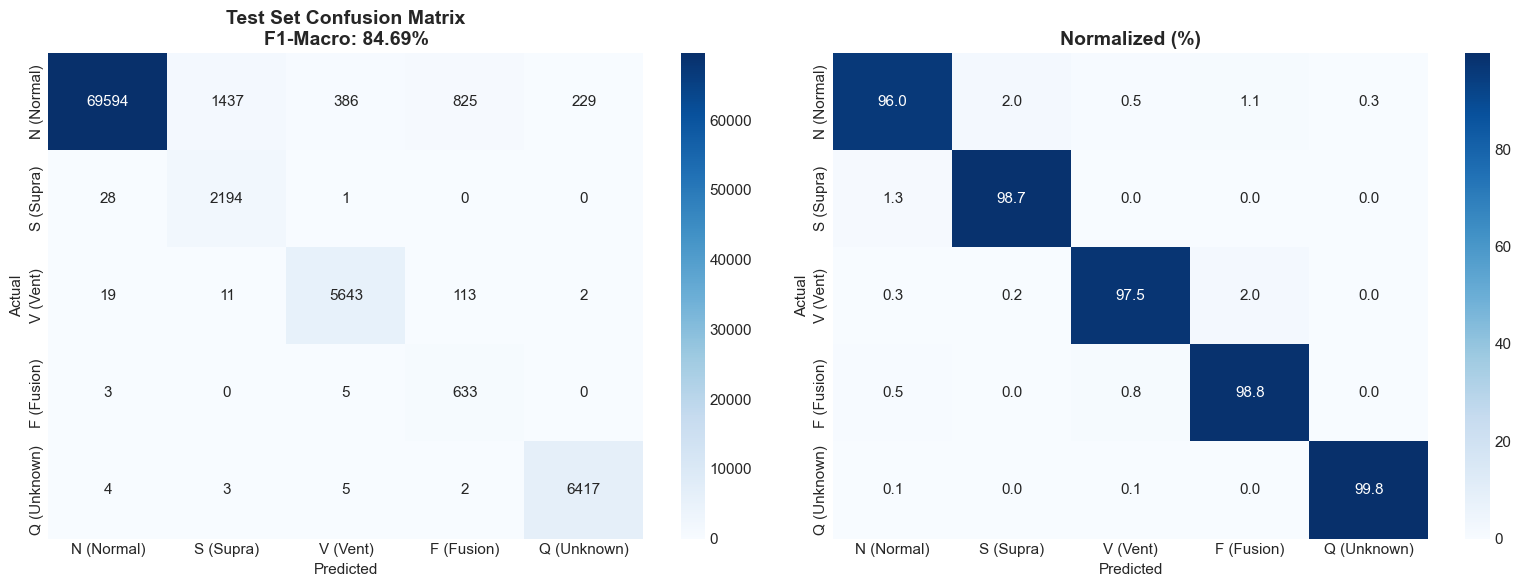

In [19]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, 
            yticklabels=CLASS_NAMES, ax=axes[0], annot_kws={'size': 11})
axes[0].set_title(f'Test Set Confusion Matrix\nF1-Macro: {f1_macro*100:.2f}%', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='Blues', xticklabels=CLASS_NAMES, 
            yticklabels=CLASS_NAMES, ax=axes[1], annot_kws={'size': 11})
axes[1].set_title('Normalized (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
print('CLASSIFICATION REPORT (Test Set)')
print('=' * 70)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))


CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

  N (Normal)     0.9992    0.9603    0.9794     72471
   S (Supra)     0.6019    0.9870    0.7478      2223
    V (Vent)     0.9343    0.9749    0.9542      5788
  F (Fusion)     0.4024    0.9875    0.5718       641
 Q (Unknown)     0.9653    0.9978    0.9813      6431

    accuracy                         0.9649     87554
   macro avg     0.7806    0.9815    0.8469     87554
weighted avg     0.9780    0.9649    0.9690     87554



## 16. Grad-CAM Visualization

In [21]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()
    
    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()
        def backward_hook(module, grad_in, grad_out):
            self.gradients = grad_out[0].detach()
        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)
    
    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = F.relu((weights * self.activations).sum(dim=1, keepdim=True))
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        return cam.squeeze().cpu().numpy(), class_idx

gradcam = GradCAM(model, model.cbam4)
print('Grad-CAM ready')


Grad-CAM ready


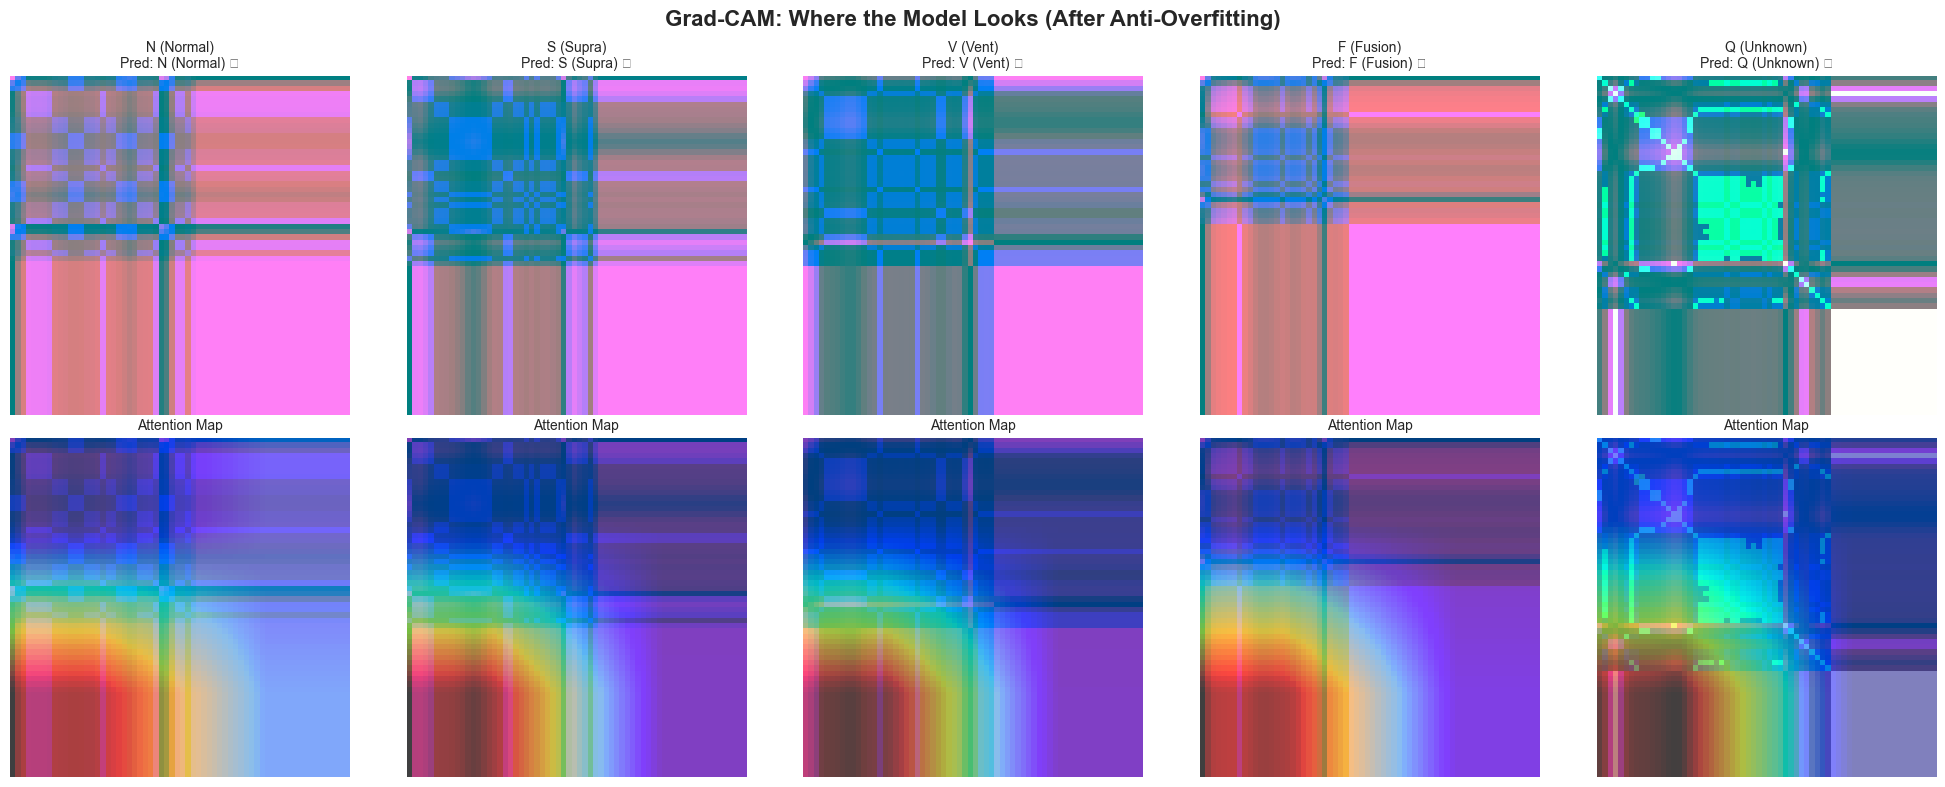

In [22]:
# GradCAM examples for each class
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Grad-CAM: Where the Model Looks (After Anti-Overfitting)', fontsize=16, fontweight='bold')

for class_idx in range(5):
    indices = np.where(y_test == class_idx)[0][:1]
    if len(indices) == 0:
        continue
    sample, label = test_dataset[indices[0]]
    sample = sample.unsqueeze(0).to(device)
    cam, pred = gradcam.generate(sample)
    
    img = sample.squeeze().cpu().numpy().transpose(1, 2, 0)
    img = (img - img.min()) / (img.max() - img.min())
    
    # Original image
    axes[0, class_idx].imshow(img)
    correct = '✓' if pred == label else '✗'
    axes[0, class_idx].set_title(f'{CLASS_NAMES[class_idx]}\nPred: {CLASS_NAMES[pred]} {correct}', fontsize=10)
    axes[0, class_idx].axis('off')
    
    # GradCAM overlay
    axes[1, class_idx].imshow(img)
    axes[1, class_idx].imshow(cam, cmap='jet', alpha=0.5)
    axes[1, class_idx].set_title('Attention Map', fontsize=10)
    axes[1, class_idx].axis('off')

plt.tight_layout()
plt.savefig('gradcam_enhanced.png', dpi=150, bbox_inches='tight')
plt.show()


## 17. Complete Pipeline Visualization

**End-to-End Flow**: Signal → Label → Encoding → Model → GradCAM → Prediction

This visualization summarizes the entire classification process.

In [23]:
def visualize_complete_pipeline(signal_idx, save_name='pipeline_visualization.png'):
    '''
    Create a comprehensive visualization of the entire pipeline
    '''
    signal = X_test[signal_idx]
    true_label = y_test[signal_idx]
    
    # Get prediction
    sample, _ = test_dataset[signal_idx]
    input_tensor = sample.unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(input_tensor)
        probs = F.softmax(output, dim=1).cpu().numpy()[0]
        pred_class = output.argmax(1).item()
    
    # Generate GradCAM
    cam, _ = gradcam.generate(input_tensor, pred_class)
    
    # Create figure
    fig = plt.figure(figsize=(24, 14))
    gs = GridSpec(3, 6, figure=fig, height_ratios=[1, 1, 0.8], hspace=0.3, wspace=0.3)
    
    # Row 1: Raw Signal + Individual Encodings
    # 1. Raw ECG Signal
    ax1 = fig.add_subplot(gs[0, 0:2])
    ax1.plot(signal, color='#e74c3c', lw=1.5, label='ECG Signal')
    ax1.fill_between(range(len(signal)), signal, alpha=0.3, color='#e74c3c')
    ax1.set_title(f'1. Raw ECG Signal\nTrue Label: {CLASS_NAMES[true_label]}', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Sample Point')
    ax1.set_ylabel('Amplitude')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. GAF
    ax2 = fig.add_subplot(gs[0, 2])
    gaf_img = gaf.transform(signal.reshape(1, -1))[0]
    im2 = ax2.imshow(gaf_img, cmap='viridis', aspect='auto')
    ax2.set_title('2. GAF\n(Gramian Angular Field)', fontsize=11, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    # 3. RP
    ax3 = fig.add_subplot(gs[0, 3])
    rp_img = create_rp(signal, CONFIG['image_size'])
    ax3.imshow(rp_img, cmap='binary', aspect='auto')
    ax3.set_title('3. RP\n(Recurrence Plot)', fontsize=11, fontweight='bold')
    ax3.axis('off')
    
    # 4. MTF
    ax4 = fig.add_subplot(gs[0, 4])
    mtf_img = create_mtf(signal, CONFIG['image_size'])
    im4 = ax4.imshow(mtf_img, cmap='plasma', aspect='auto')
    ax4.set_title('4. MTF\n(Markov Transition Field)', fontsize=11, fontweight='bold')
    ax4.axis('off')
    plt.colorbar(im4, ax=ax4, fraction=0.046, pad=0.04)
    
    # 5. Fusion
    ax5 = fig.add_subplot(gs[0, 5])
    fusion = np.stack([gaf_img, rp_img, mtf_img], axis=-1)
    fusion_norm = (fusion - fusion.min()) / (fusion.max() - fusion.min())
    ax5.imshow(fusion_norm)
    ax5.set_title('5. Fusion\n(3-Channel Input)', fontsize=11, fontweight='bold')
    ax5.axis('off')
    
    # Row 2: Model + GradCAM + Prediction
    # 6. Model Architecture
    ax6 = fig.add_subplot(gs[1, 0:2])
    ax6.axis('off')
    arch_text = '''
    CBAM-ResNet18 Enhanced
    ━━━━━━━━━━━━━━━━━━━━━━
    Conv1 → BN → ReLU → MaxPool
         ↓
    Layer1 → CBAM → StochasticDepth
         ↓
    Layer2 → CBAM
         ↓
    Layer3 → CBAM → DropBlock
         ↓
    Layer4 → CBAM → DropBlock
         ↓
    AvgPool → Dropout → FC → Pred
    '''
    ax6.text(0.5, 0.5, arch_text, transform=ax6.transAxes, fontsize=10,
             verticalalignment='center', horizontalalignment='center',
             fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    ax6.set_title('6. Model Architecture', fontsize=11, fontweight='bold')
    
    # 7. GradCAM on each channel
    ax7 = fig.add_subplot(gs[1, 2])
    ax7.imshow(gaf_img, cmap='gray')
    ax7.imshow(cam, cmap='jet', alpha=0.5)
    ax7.set_title('7a. GradCAM on GAF', fontsize=10, fontweight='bold')
    ax7.axis('off')
    
    ax8 = fig.add_subplot(gs[1, 3])
    ax8.imshow(rp_img, cmap='gray')
    ax8.imshow(cam, cmap='jet', alpha=0.5)
    ax8.set_title('7b. GradCAM on RP', fontsize=10, fontweight='bold')
    ax8.axis('off')
    
    ax9 = fig.add_subplot(gs[1, 4])
    ax9.imshow(fusion_norm)
    ax9.imshow(cam, cmap='jet', alpha=0.5)
    ax9.set_title('7c. Combined Attention', fontsize=10, fontweight='bold')
    ax9.axis('off')
    
    # 8. Prediction
    ax10 = fig.add_subplot(gs[1, 5])
    colors = [CLASS_COLORS[i] if i == pred_class else '#bdc3c7' for i in range(5)]
    bars = ax10.barh(CLASS_NAMES, probs * 100, color=colors, edgecolor='black')
    ax10.set_xlabel('Probability (%)')
    ax10.set_title('8. Prediction', fontsize=11, fontweight='bold')
    ax10.set_xlim(0, 105)
    for bar, p in zip(bars, probs):
        ax10.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                  f'{p*100:.1f}%', va='center', fontsize=9)
    
    # Row 3: Result Summary
    ax_result = fig.add_subplot(gs[2, :])
    ax_result.axis('off')
    
    is_correct = pred_class == true_label
    result_color = '#27ae60' if is_correct else '#e74c3c'
    result_text = 'CORRECT PREDICTION' if is_correct else 'INCORRECT PREDICTION'
    
    # Draw result box
    result_summary = f'''
    ╔══════════════════════════════════════════════════════════════════════════════════════════╗
    ║                                    CLASSIFICATION RESULT                                  ║
    ╠══════════════════════════════════════════════════════════════════════════════════════════╣
    ║  True Label:     {CLASS_NAMES[true_label]:<20}                                         ║
    ║  Predicted:      {CLASS_NAMES[pred_class]:<20}                                         ║
    ║  Confidence:     {probs[pred_class]*100:.2f}%                                                              ║
    ║  Result:         {result_text:<25}                                    ║
    ╚══════════════════════════════════════════════════════════════════════════════════════════╝
    '''
    
    ax_result.text(0.5, 0.5, result_summary, transform=ax_result.transAxes, fontsize=12,
                   verticalalignment='center', horizontalalignment='center',
                   fontfamily='monospace', 
                   bbox=dict(boxstyle='round', facecolor=result_color, alpha=0.3))
    
    plt.suptitle('Complete ECG Classification Pipeline', fontsize=16, fontweight='bold', y=0.98)
    plt.savefig(save_name, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return pred_class, true_label, probs

print('Pipeline visualization function ready')


Pipeline visualization function ready


Generating Complete Pipeline Visualizations...

Visualizing N (Normal) (sample 0)...


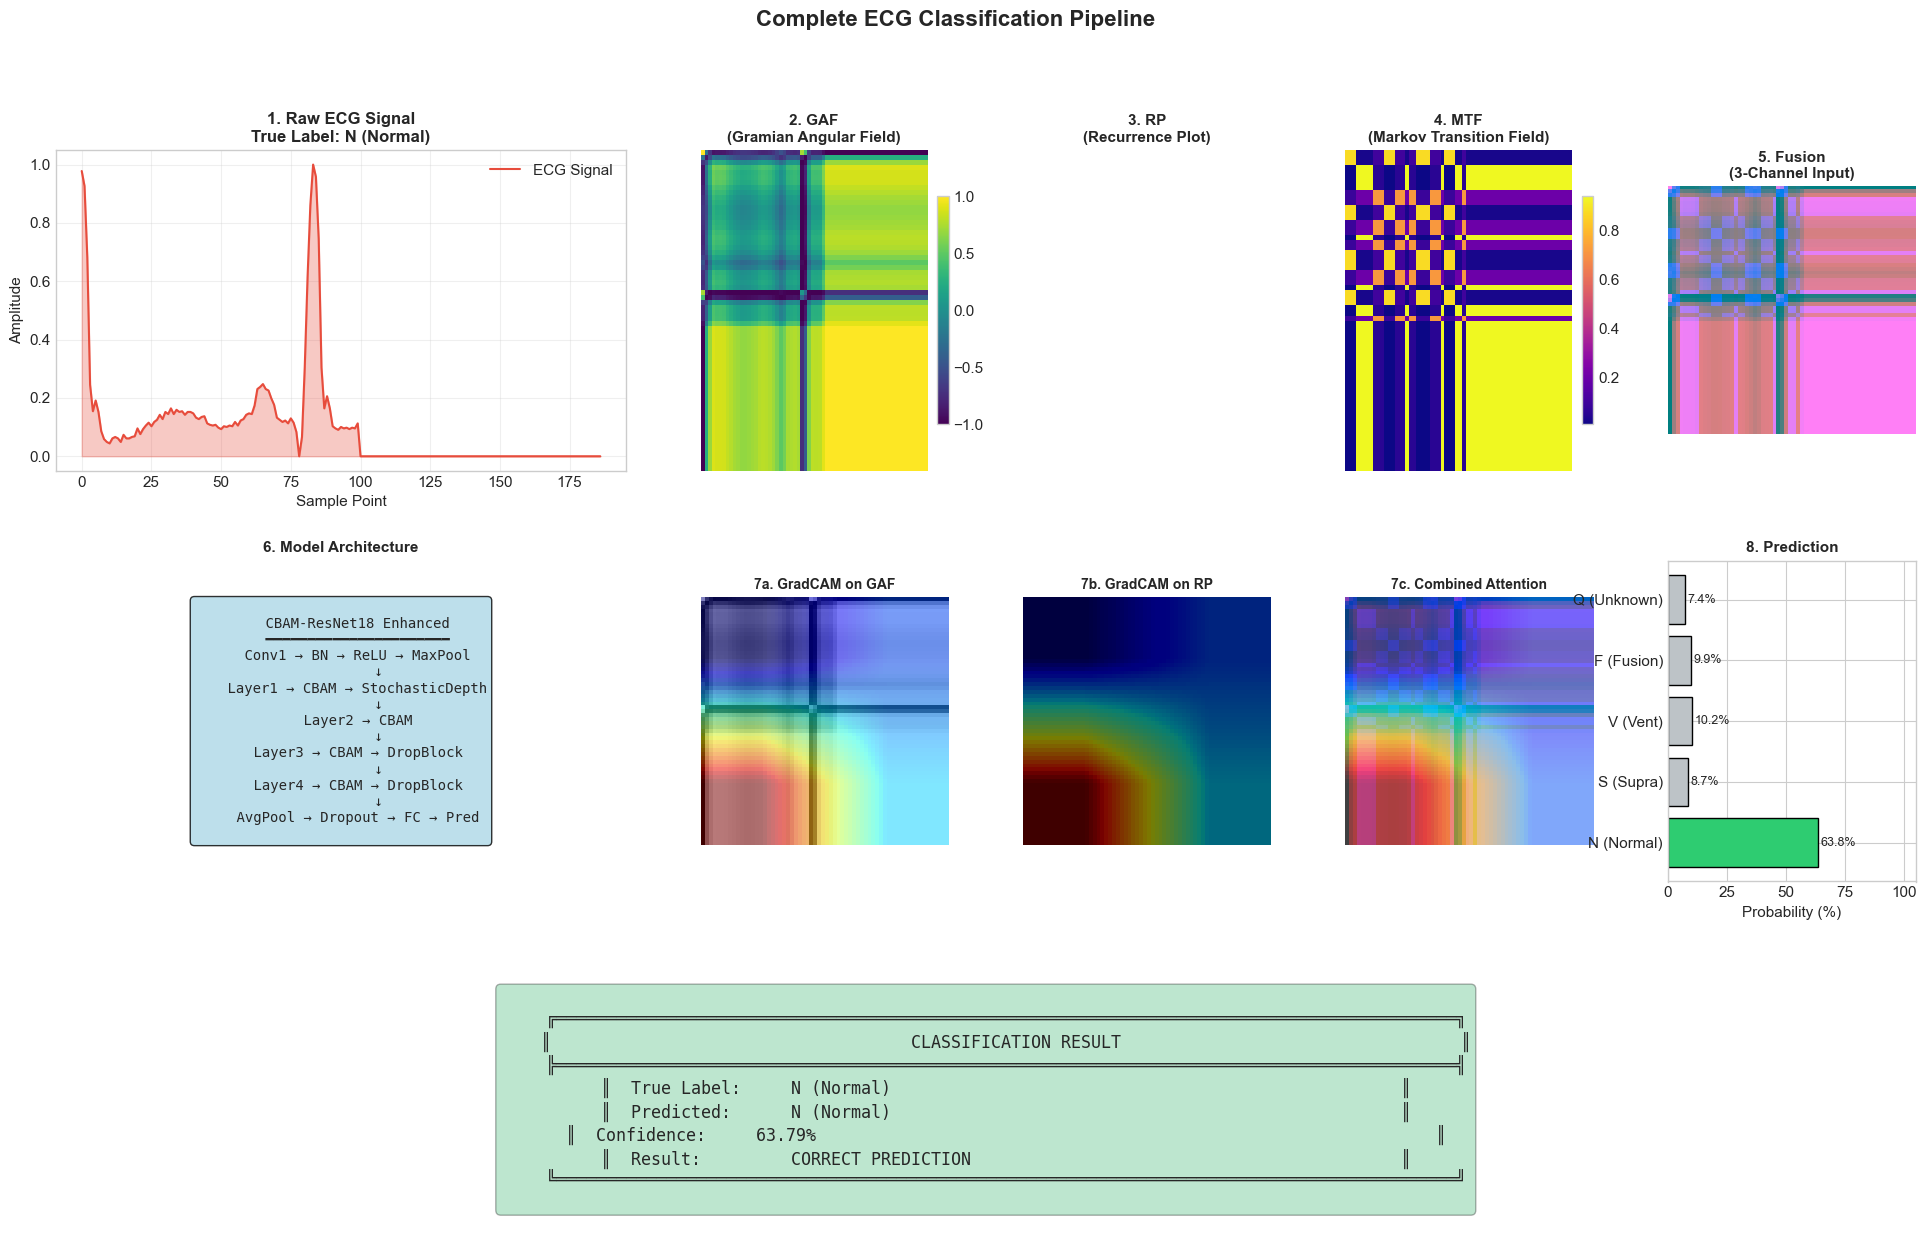

  True: N (Normal), Pred: N (Normal), Conf: 63.8%

Visualizing S (Supra) (sample 72471)...


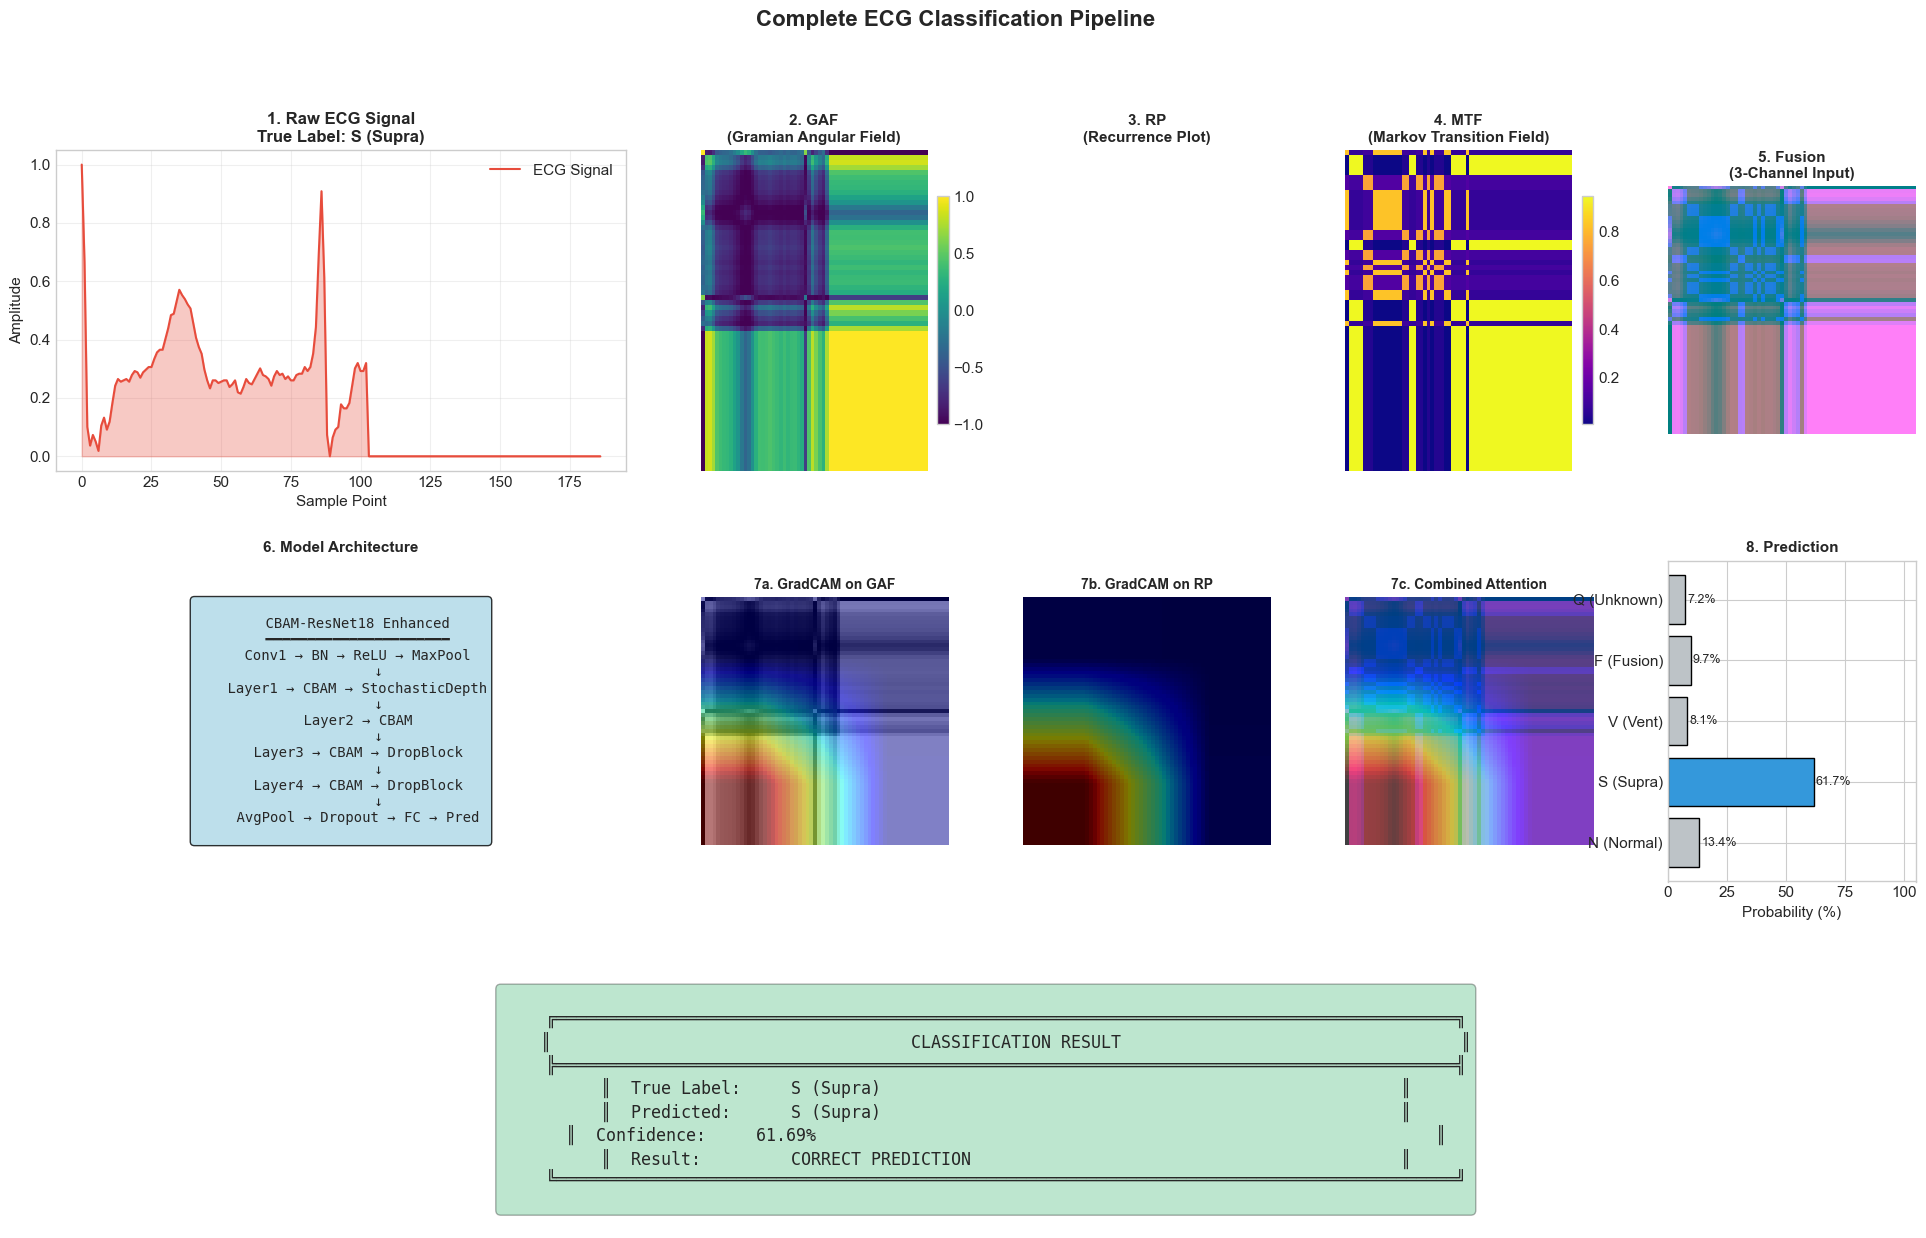

  True: S (Supra), Pred: S (Supra), Conf: 61.7%

Visualizing V (Vent) (sample 74694)...


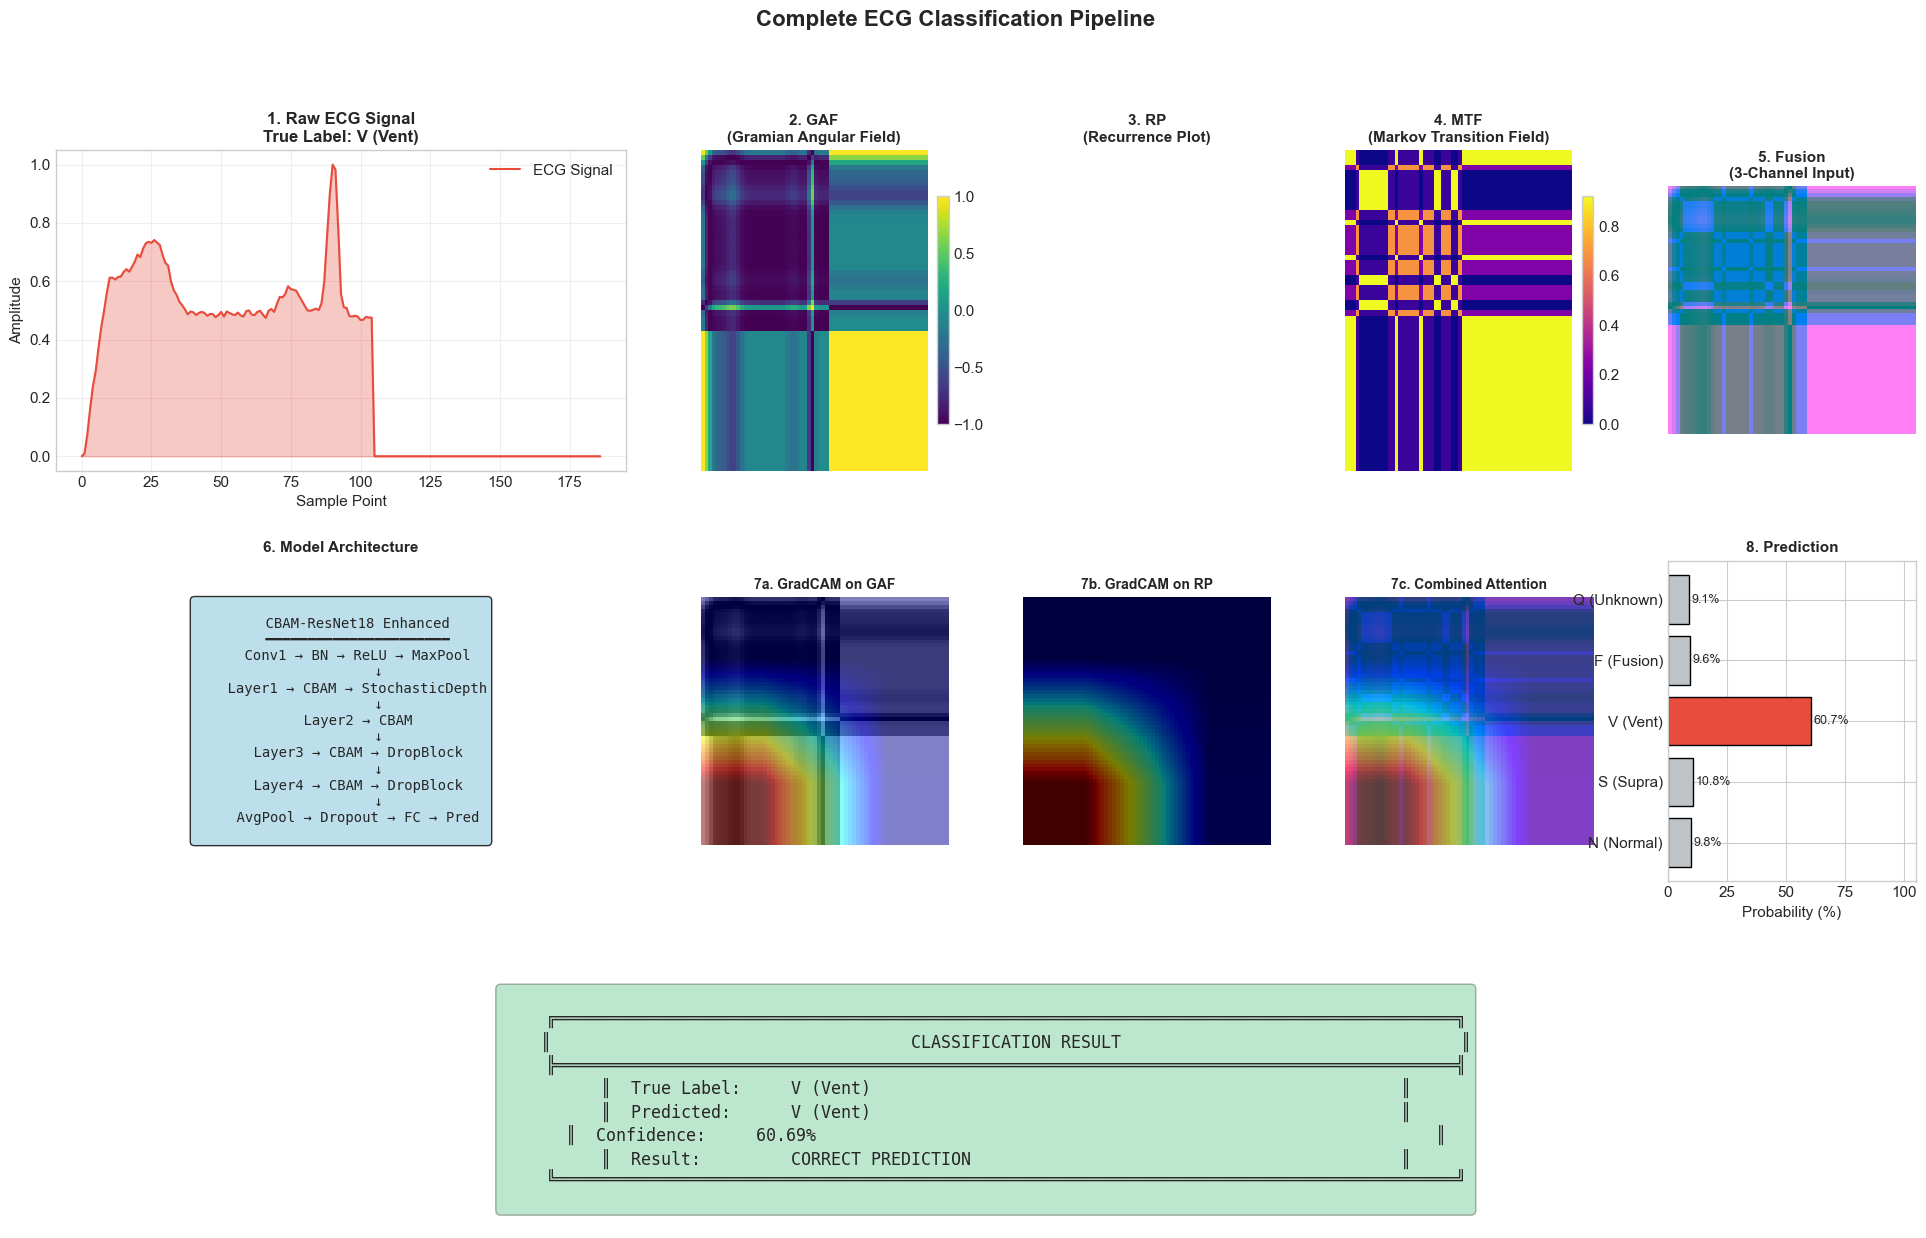

  True: V (Vent), Pred: V (Vent), Conf: 60.7%

Visualizing F (Fusion) (sample 80482)...


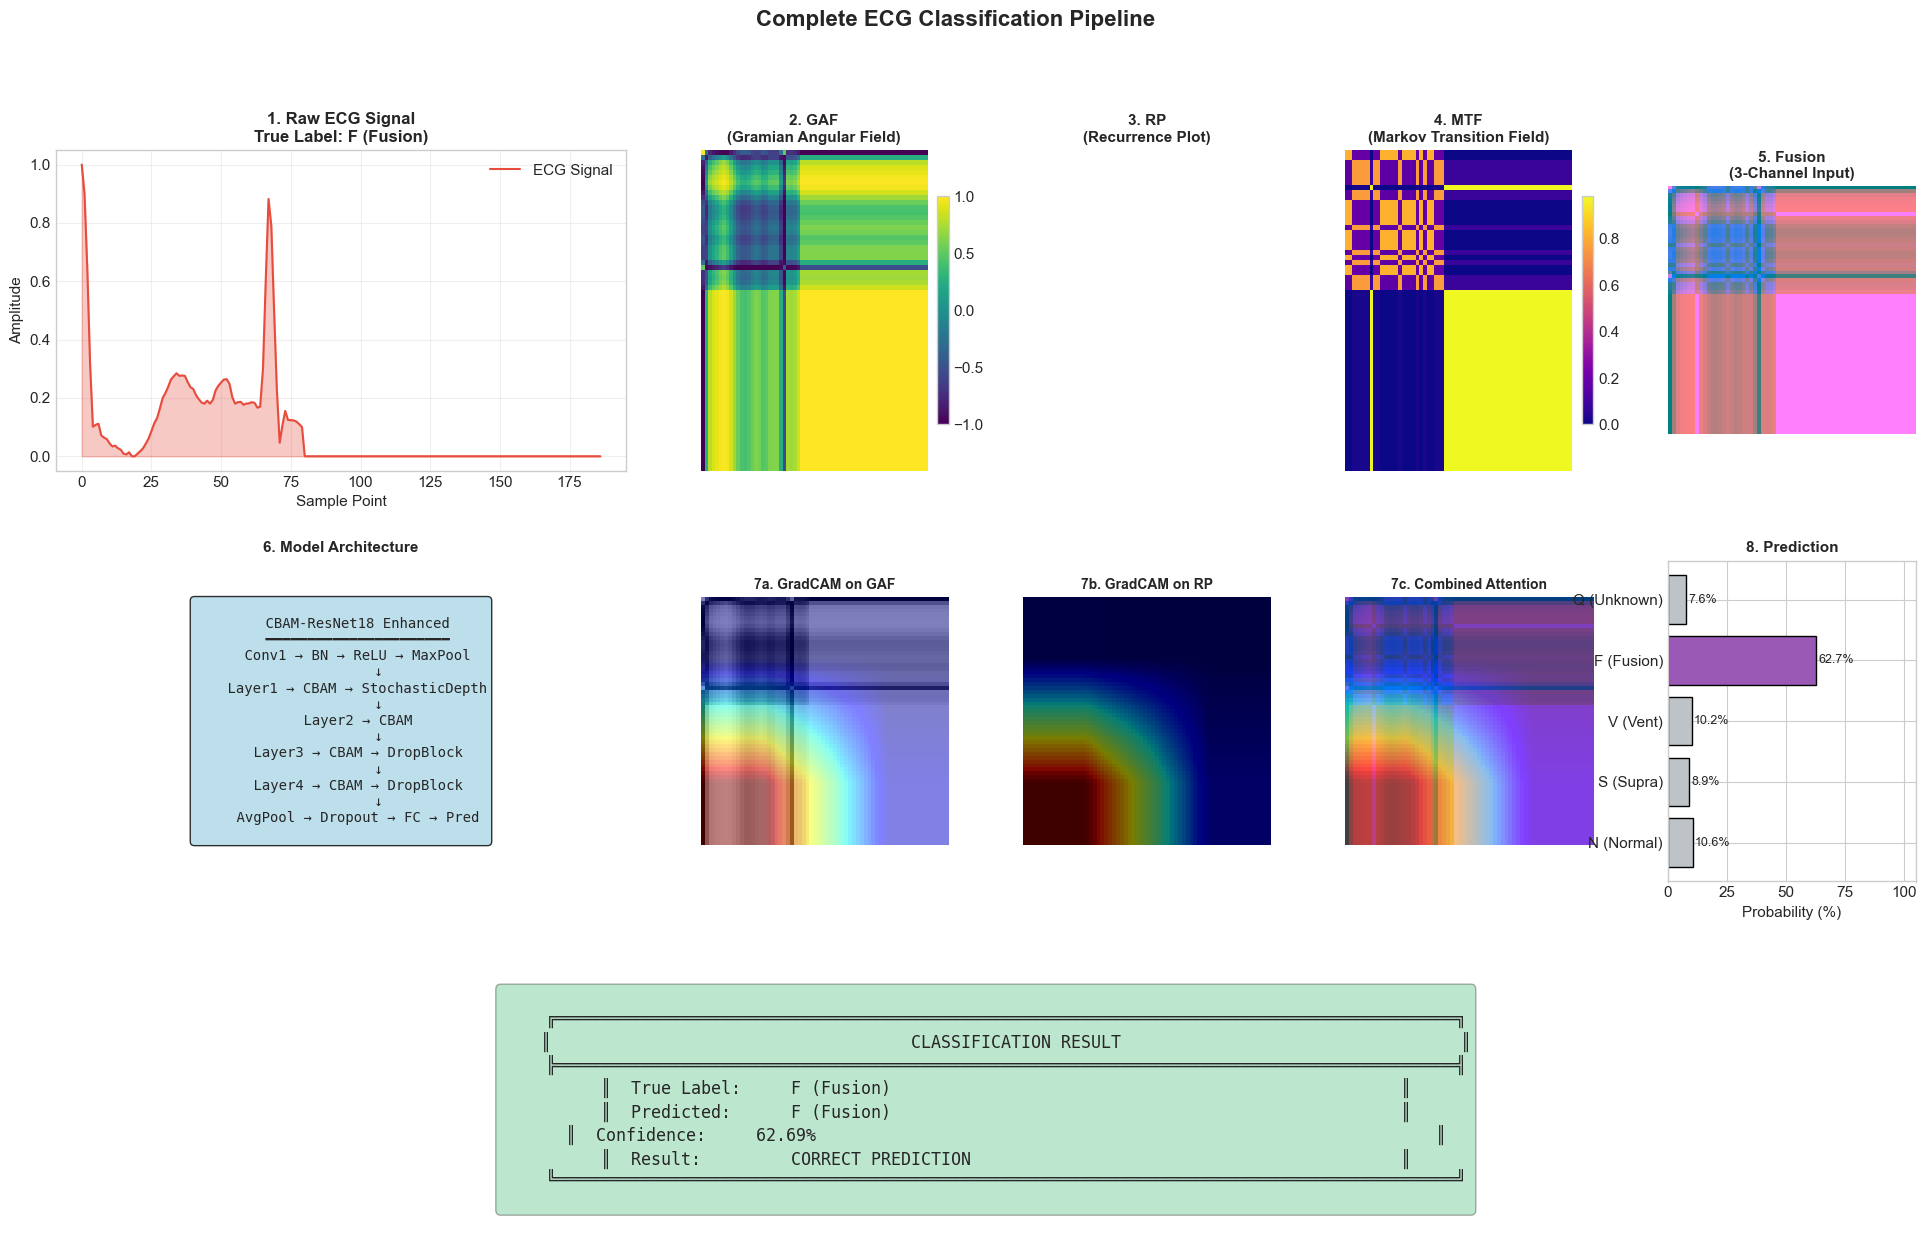

  True: F (Fusion), Pred: F (Fusion), Conf: 62.7%

Visualizing Q (Unknown) (sample 81123)...


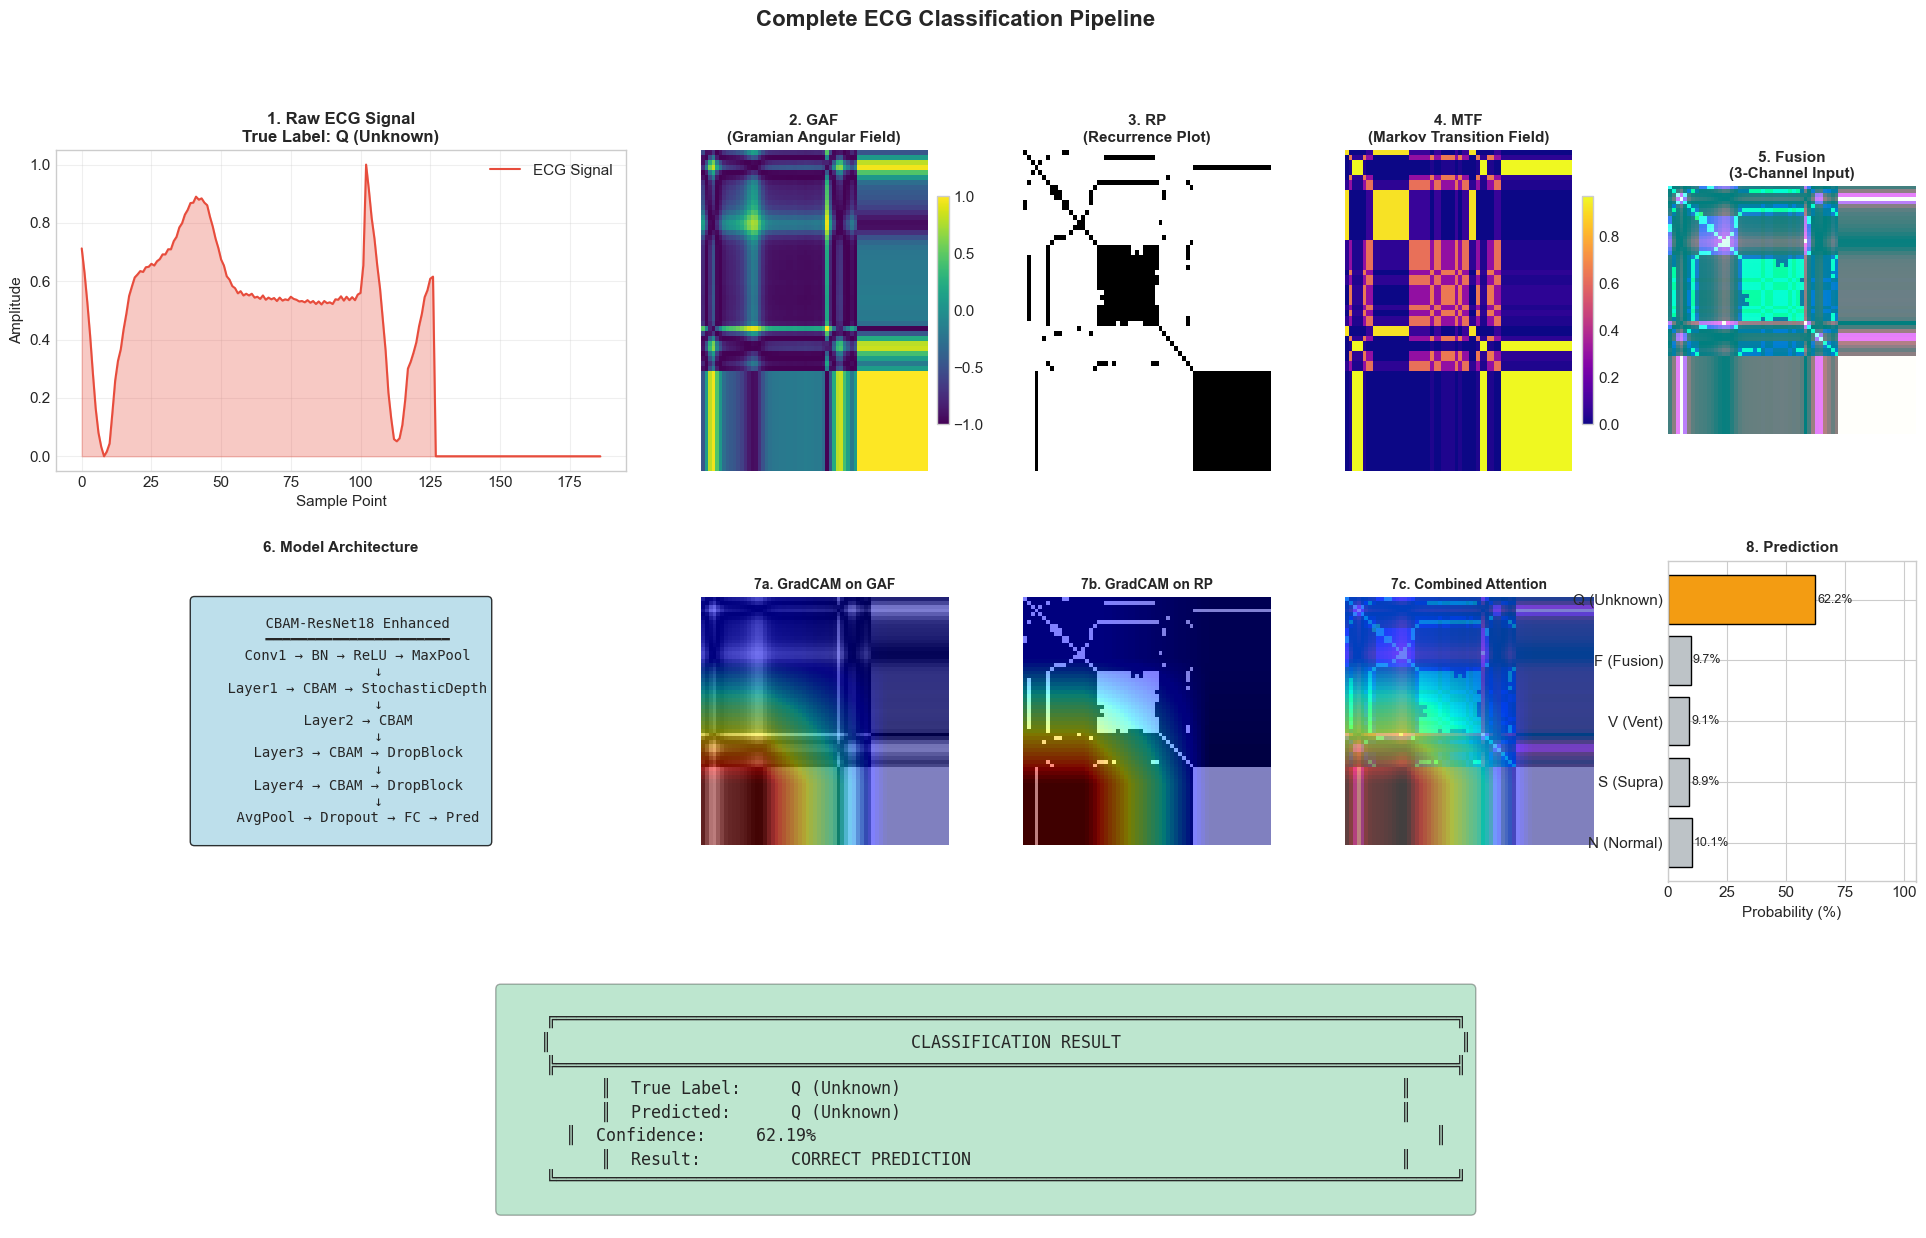

  True: Q (Unknown), Pred: Q (Unknown), Conf: 62.2%



In [24]:
# Generate pipeline visualizations for different classes
print('Generating Complete Pipeline Visualizations...')
print()

for class_idx in range(5):
    # Find a sample of this class
    class_indices = np.where(y_test == class_idx)[0]
    if len(class_indices) > 0:
        sample_idx = class_indices[0]
        print(f'Visualizing {CLASS_NAMES[class_idx]} (sample {sample_idx})...')
        pred, true, probs = visualize_complete_pipeline(
            sample_idx, 
            save_name=f'pipeline_class_{class_idx}.png'
        )
        print(f'  True: {CLASS_NAMES[true]}, Pred: {CLASS_NAMES[pred]}, Conf: {probs[pred]*100:.1f}%')
        print()


## 18. Results Summary

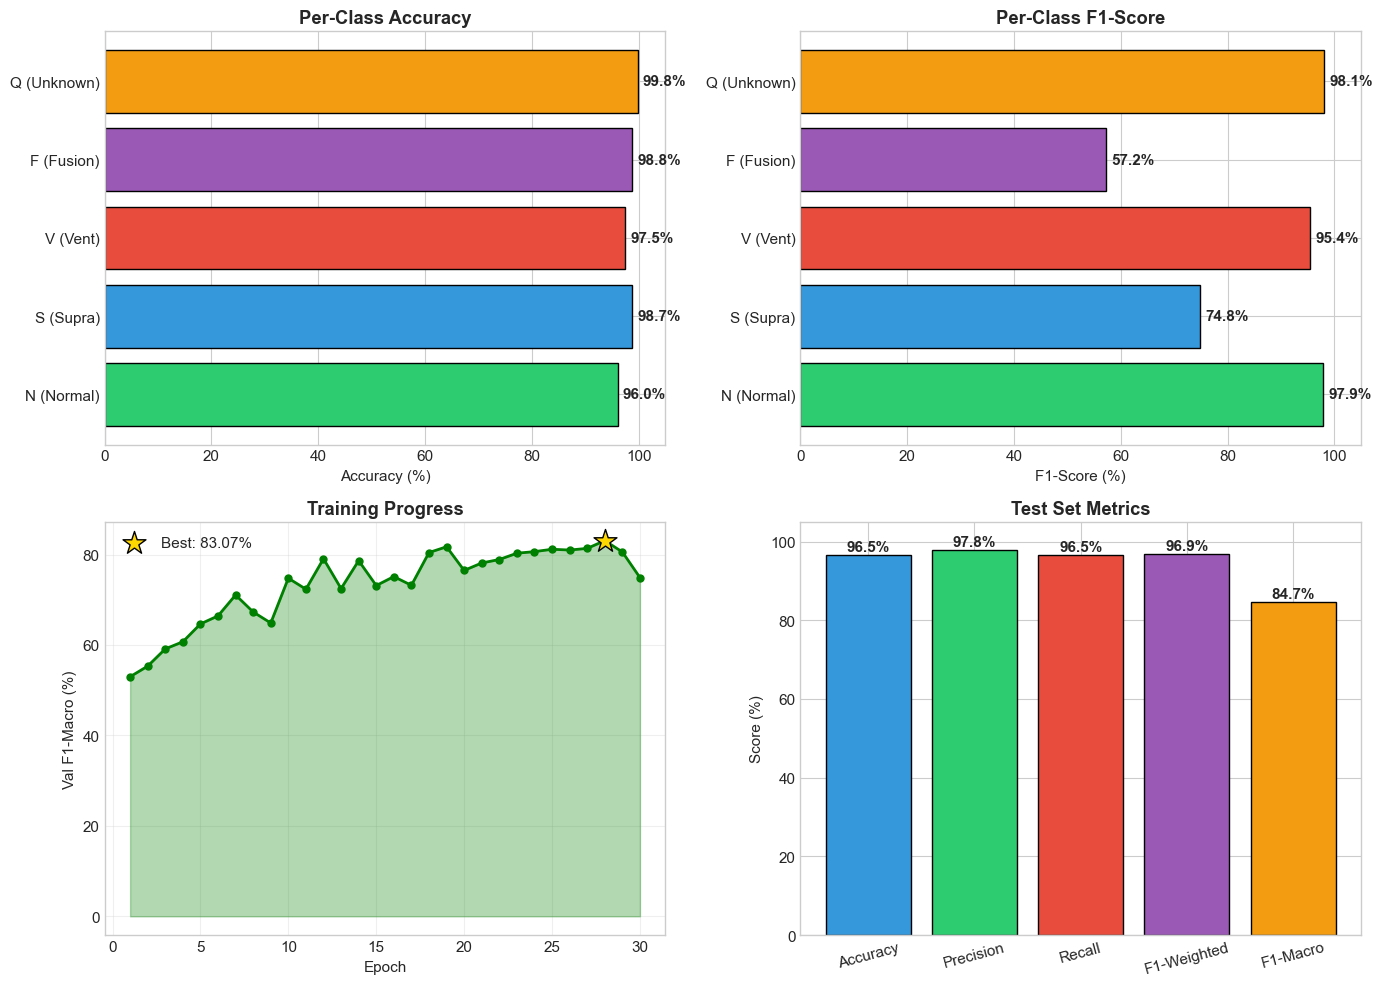

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Per-class accuracy
per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars = axes[0, 0].barh(CLASS_NAMES, per_class_acc * 100, color=CLASS_COLORS, edgecolor='black')
axes[0, 0].set_xlabel('Accuracy (%)')
axes[0, 0].set_title('Per-Class Accuracy', fontweight='bold')
axes[0, 0].set_xlim(0, 105)
for bar, acc in zip(bars, per_class_acc):
    axes[0, 0].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                    f'{acc*100:.1f}%', va='center', fontweight='bold')

# Per-class F1
per_class_f1 = f1_score(all_labels, all_preds, average=None)
bars = axes[0, 1].barh(CLASS_NAMES, per_class_f1 * 100, color=CLASS_COLORS, edgecolor='black')
axes[0, 1].set_xlabel('F1-Score (%)')
axes[0, 1].set_title('Per-Class F1-Score', fontweight='bold')
axes[0, 1].set_xlim(0, 105)
for bar, f1_val in zip(bars, per_class_f1):
    axes[0, 1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                    f'{f1_val*100:.1f}%', va='center', fontweight='bold')

# Training Progress
axes[1, 0].fill_between(range(1, len(history['val_f1'])+1), [x*100 for x in history['val_f1']], alpha=0.3, color='green')
axes[1, 0].plot(range(1, len(history['val_f1'])+1), [x*100 for x in history['val_f1']], 'g-o', lw=2, ms=5)
axes[1, 0].scatter([best_epoch], [best_f1*100], s=300, c='gold', marker='*', edgecolors='black', zorder=5, label=f'Best: {best_f1*100:.2f}%')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Val F1-Macro (%)')
axes[1, 0].set_title('Training Progress', fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Overall Metrics Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Weighted', 'F1-Macro']
values = [accuracy, precision, recall, f1_weighted, f1_macro]
colors_m = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']
bars = axes[1, 1].bar(metrics, [v*100 for v in values], color=colors_m, edgecolor='black')
axes[1, 1].set_ylabel('Score (%)')
axes[1, 1].set_title('Test Set Metrics', fontweight='bold')
axes[1, 1].set_ylim(0, 105)
for bar, val in zip(bars, values):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                    f'{val*100:.1f}%', ha='center', fontweight='bold')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('results_summary.png', dpi=150, bbox_inches='tight')
plt.show()


## Conclusion

### Anti-Overfitting Techniques Applied

| Technique | Implementation | Effect |
|-----------|---------------|--------|
| **DropBlock** | 7x7 blocks, p=0.15 in layer3/4 | Prevents spatial over-reliance |
| **Stochastic Depth** | Linear decay to 0.8 survival | Implicit ensemble of networks |
| **CutMix** | Beta=1.0, p=0.5 | Simulates temporal splicing |
| **Focal Loss** | gamma=2.0 | Focuses on hard minority samples |
| **Label Smoothing** | epsilon=0.1 | Prevents overconfident predictions |
| **1D Signal Aug** | Noise + time warp | Increases diversity safely |
| **Cosine Annealing** | T_max=30 epochs | Smooth LR decay for convergence |
| **Weight Decay** | 5e-4 (1e-3 for CBAM) | L2 regularization |

### Key Insights from Research

1. **CutMix > MixUp** for GAF/RP/MTF: MixUp creates meaningless blends, CutMix simulates temporal segment splicing
2. **DropBlock Essential**: Standard Dropout fails due to spatial correlation in CNNs
3. **Focal Loss Critical**: Addresses severe class imbalance (83% Normal class)
4. **Signal Augmentation**: Apply BEFORE encoding to preserve mathematical validity

### References

- Ghiasi et al. (2018): DropBlock
- Huang et al. (2016): Stochastic Depth  
- Yun et al. (2019): CutMix
- Lin et al. (2017): Focal Loss
- Research on MIT-BIH arrhythmia classification with CBAM-ResNet
